In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
import control as ct

from scipy.linalg import block_diag
from matplotlib import pyplot as plt
from collections import namedtuple

import kind
import utils_data
import utils_nn

In [2]:
# --! define helping routines for simulations --!

def make_rf_a(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [-hbw,     0.],
        [ 0.,    -hbw],
    ])

def make_rf_b(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [hbw,    0.],
        [0.,    hbw],
    ])

def make_mm_a(f, q):
    """Constructs the matrix A of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q],
    ])

def make_mm_b(f, k):
    """Constructs the matrix B of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [0               ],
        [k * np.square(w)],
    ])

def make_mm_system(f=np.array([100.]), q=np.array([1000.]), k=np.array([1.]), dt=0.):
    a = block_diag(*[make_mm_a(f, q) for f, q in zip(f, q)])
    b = np.concatenate([make_mm_b(f, k) for f, k in zip(f, k)], axis=0)
    c = np.tile(np.array([[1, 0]]), len(f))
    d = np.array(([[0]]))

    return ct.ss(a, b, c, d, dt, name='mm_plant')

def cavity_update(t, x, u, param):

    # --! get parameters
    rf_f = param.get('rf_f')
    rf_q = param.get('rf_q')
    rf_v = param.get('rf_v')
    rf_len = param.get('rf_len')
    mm_control_used = param.get('mm_control_used')
    mm_f = param.get('mm_f')
    mm_q = param.get('mm_q')
    nmm = len(mm_f)
    mm_k = param.get('mm_k')
    mm_t = param.get('mm_t')

    # --! extract current state of a cavity field: real and imaginary components
    rf_x = np.array(x[:2]).reshape((-1, 1))

    # --! extract current states of all mechanical modes: displacements and velocities
    mm_x = np.array(x[2:]).reshape((-1, 1))

    # --! assemble input to cavity field: real and imaginary parts of a generator voltage
    rf_u = np.array([
        [rf_v[0]],
        [rf_v[1]]
    ])

    # --! compute input to mechanical mode: accelerating field gradient squared
    #
    # --! field gradient has units MV/m, but since we simulate only one cell,
    # --! and the length of one cell is passed as a parameter,
    # --! we need to adjust the total gradient
    rf_grad = np.sqrt(np.square(rf_x[0]) + np.square(rf_x[1]))
    rf_grad = rf_grad * rf_len
    rf_grad = np.square(rf_grad)

    # --! create rf matrices A and B
    rf_a = make_rf_a(rf_f, rf_q)
    rf_b = make_rf_b(rf_f, rf_q)

    # --! update detuning in rf matrix A
    mm_disp = np.sum([mm_x[2*j] for j in range(nmm)])
    rf_a[0, 1] = -mm_disp
    rf_a[1, 0] =  mm_disp

    # --! assemble mechanical mode matrices: A and B
    mm_a = block_diag(*[make_mm_a(f, q) for f, q in zip(mm_f, mm_q)])
    mm_b_field = np.concatenate([make_mm_b(f, k) for f, k in zip(mm_f, mm_k)], axis=0)
    mm_b_control = np.concatenate([make_mm_b(f, k) for f, k in zip(mm_f, mm_k)], axis=0)

    # --! split matrix B of mechanical modes into per-mode B matrices
    mm_b_mode = np.split(mm_b_field, mm_b_field.shape[0] // 2, axis=0)

    # --! split mechanical time boundary array into per-mode parts
    mm_t_mode = np.split(mm_t, mm_t.shape[0], axis=0) # split into rows

    for mat, timespan in zip(mm_b_mode, mm_t_mode):
        if not (timespan[0, 0] <= t and t < timespan[0, 1]):
            mat[:] = 0.

    # --! mechanical modes are excited by field gradient ...
    mm_u_field = rf_grad

    mm_u_control = 0.
    if mm_control_used:
        # --! ... and compensated by control (if used)
        mm_u_control = u

    # --! calculate derivatives
    rf_dx = rf_a @ rf_x + rf_b @ rf_u
    mm_dx = mm_a @ mm_x + mm_b_field * mm_u_field + mm_b_control * mm_u_control

    return np.array([
        *rf_dx.flatten(),
        *mm_dx.flatten(),
    ])

def cavity_output(t, x, u, param):
    """ Outputs summed positions of all mechanical modes, i.e. cavity detuning. """
    mm_x = x[2:]
    nmm  = len(mm_x) // 2
    mm_d = np.sum([mm_x[2*j] for j in range(nmm)])
    return np.array([mm_d])


class lookback:
    def __init__(self, window_nsample=96):
        self.window = torch.zeros(window_nsample, 3)
        self.count = 0

    def update(self, detuning, control):
        if not self.ready():
            control = 0.
            mask = 0.
        else:
            mask = 1.

        sample = np.array([[detuning, control, mask]])
        sample = torch.from_numpy(sample)
        self.window = torch.cat([self.window[1:], sample], dim=0)
        self.count = self.count + 1

    def ready(self):
        return self.count >= self.window.shape[0]

    def get_window(self):
        return torch.unsqueeze(self.window, 0).to(torch.float32)


def sim_cavity_control(
    model, policy,
    dt_control=1e-3, dt_sim=1e-6, t_final=0.3,
    mm_f=np.array([40.]), mm_q=np.array([400.]), mm_k=np.array([1.]), mm_t=np.array([[-1., -1.]])):
    """ Simulates cavity equations under control. """

    # --! actualize time boundaries
    for timespan in np.split(mm_t, mm_t.shape[0], axis=0): # split into rows
        if timespan[0, 0]==-1.:
            timespan[0, 0] = 0.
        if timespan[0, 1]==-1.:
            timespan[0, 1] = t_final

    # --! prepare parameters for cavity plant simulation
    cavity_param = {
        'rf_f' : 1.3e9,
        'rf_q' : 4e6,
        'rf_v' : [9.5, 0.],
        'rf_len' : 0.1615,
        'mm_control_used' : True,
        'mm_f' : mm_f,
        'mm_q' : mm_q,
        'mm_k' : mm_k,
        'mm_t' : mm_t,
    }

    # --! number of cavity states includes two rf states and the number of mechaical modes times two
    nstate = 2 + 2 * len(cavity_param.get('mm_f'))

    # --! wrap a cavity plant in a nonlinear input/output system
    cavity = ct.nlsys(
        cavity_update, cavity_output,
        states=nstate,
        name='cavity',
        inputs=1, outputs=1,
        params=cavity_param)

    cavity_state = np.zeros(cavity.nstates)
    back = lookback()
    u = 0.0
    detuning_log, control_log = [], []

    for step in range(int(t_final / dt_control)):

        # integrate continuous plant for dt_control with current control value (held constant)
        t_local = np.arange(0, dt_control, dt_sim)
        u_local = np.full_like(t_local, u)
        _, y_local, x_local = ct.input_output_response(
            cavity,
            t_local,
            inputs=u_local, initial_state=cavity_state, return_states=True)

        # take last integrated values for the cavity state and detuning
        cavity_state = x_local[:, -1]
        detuning = y_local[-1]

        back.update(detuning, u)

        # --! call discrete control (once per control period)
        if back.ready():
            window = back.get_window()
            s_next = model(window)[0][:, window.shape[1]:]
            a_next = policy(s_next)
            u = a_next[0, 0, 0].detach().numpy()

        # --! log data
        detuning_log.append(detuning)
        control_log.append(u)

    return detuning_log, control_log


# --! mechanical mode properties
mechanical_mode = namedtuple('mechanical_mode', 'f q k t')

In [3]:
# --! load kind model --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-rl-policy-eval',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 6, "cos": 6}',
        '--fun_trans', '{"data": 10}',
    ]
)

model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

model(
  (stationary): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=72, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=1728, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=36, out_features=12, bias=False)
    (mod_mean): Linear(in_features=12, out_features=12, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=864, bia

In [4]:
# --! load policy --!

policy_path = '../../models/delay/policy/checkpoint.pth'
policy_ni = 1
policy_no = 1
policy = utils_nn.fcnn(feat=[policy_ni, 64, 64, policy_no], actfun_hid='relu')
policy.load_state_dict(torch.load(policy_path, weights_only=True))
policy.eval()

fcnn(
  (net): Sequential(
    (0): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): ReLU()
    )
    (1): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
    )
    (2): Sequential(
      (0): Linear(in_features=64, out_features=1, bias=True)
      (1): Identity()
    )
  )
)

In [5]:
mm100 = mechanical_mode(100., 1000., 0.3, [-1., -1.])
mm40 = mechanical_mode(40., 400., 0.1, [-1., -1.])
mm10 = mechanical_mode(10., 100., 0.1, [-1., -1.])

detuning_log, control_log = sim_cavity_control(model, policy,
    mm_f=np.array([mm100.f, mm40.f, mm10.f]),
    mm_q=np.array([mm100.q, mm40.q, mm10.q]),
    mm_k=np.array([mm100.k, mm40.k, mm10.k]),
    mm_t=np.array([mm100.t, mm40.t, mm10.t]))


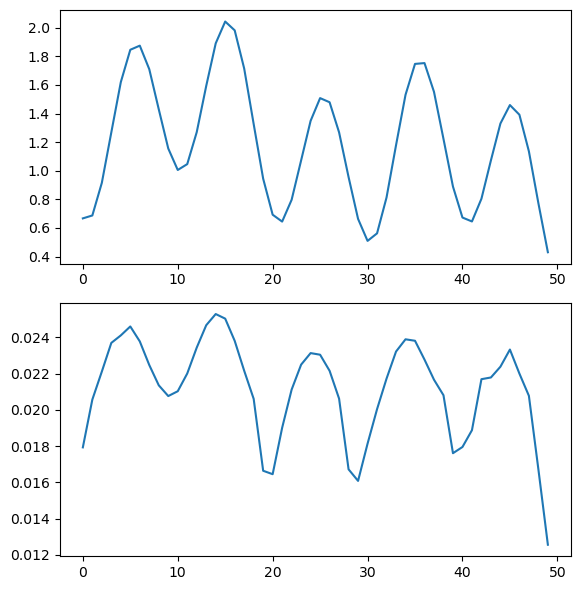

In [7]:
plt.figure(figsize=(6,6))

plt.subplot(2,1,1)
plt.plot(detuning_log[150:200])

plt.subplot(2,1,2)
plt.plot(control_log[150:200])

plt.tight_layout()
plt.show()